# Conic point pairs — analysis

The CCGA conic **point pair** `pp = p1 ^ p2` (grade 2), analysed across three
input families:

1. **real** — conic points with positive radius (`r^2 > 0`),
2. **imaginary** — conic points with negative radius (`r^2 < 0`),
3. **ideal** — ideal conic points (`w = 0`), with +/- radius.

Key fact (verified in §4): the pair's reality is governed by
$$pp^2 = \tfrac14\,(d^2 - R_1 - R_2)^2 - R_1 R_2,\qquad R_i = p_i^2,\ d=\lVert c_1-c_2\rVert,$$
so it depends on the **configuration**, not just the sign of the input radius.

Select the **CCGA (.venv)** kernel.

In [1]:
import numpy as np, sympy as sp
import matplotlib.pyplot as plt
from ccga.algebra import e1, e2, eo, einf, einf1, einf2, einf3
from ccga.point import point
from ccga.objects import make_point_ccga, make_ideal_point
from ccga.operations import grades, is_zero
from ccga.classify import reality, classify
from ccga import to_null_basis

def conic_point(x, y, R=0.0):
    # conic point with signed radius^2 R  (p^2 = R): R>0 real, R<0 imaginary, R=0 plain
    return eo + x*e1 + y*e2 + (x**2/2)*einf1 + (y**2/2)*einf2 + x*y*einf3 - (R/2)*einf

def sq(mv):
    s = mv*mv
    return float(s.e) if 0 in [bin(k).count('1') for k in s.keys()] else 0.0

def _norm_pt(P):
    P = P*(1.0/(-float((P|einf).e)))
    return float((P|e1).e), float((P|e2).e), sq(P)

def recover(pp):
    # split a point pair into center (midpoint) + the two endpoints when real
    ppsq = sq(pp); den = -(einf | pp); den2 = sq(den)
    if abs(den2) < 1e-12:
        return dict(reality='degenerate/ideal', pp2=ppsq, center=None, points=None)
    inv = den*(1.0/den2)
    cx, cy, _ = _norm_pt(pp*inv)                       # s^0 part = midpoint
    if ppsq > 1e-9:
        s = ppsq**0.5
        Pp, Pm = _norm_pt((pp+s)*inv), _norm_pt((pp-s)*inv)
        return dict(reality='real', pp2=ppsq, center=(cx, cy),
                    points=((Pp[0], Pp[1]), (Pm[0], Pm[1])))
    if ppsq < -1e-9:
        return dict(reality='imaginary', pp2=ppsq, center=(cx, cy), points=None)
    return dict(reality='tangent', pp2=ppsq, center=(cx, cy), points=None)

def pp_square_formula(x1, y1, R1, x2, y2, R2):
    d2 = (x1-x2)**2 + (y1-y2)**2
    return 0.25*(d2 - R1 - R2)**2 - R1*R2

def report(pp, label=''):
    print('---', label, '---')
    print('  grade   :', grades(pp), '  pp^2 :', round(sq(pp), 4))
    print('  reality :', reality(pp), '  type:', classify(pp)['type'],
          '  finite:', not is_zero(pp | einf))
    print('  recover :', recover(pp))

## 1. Real conic point pairs  (`pp^2 > 0` -> two real points)

In [2]:
# (a) two plain points (radius 0)
report(point(2, 0) ^ point(-2, 0), 'plain points (2,0),(-2,0)')

# (b) two real circles (R = +4, radius 2), WELL SEPARATED -> still a real pair
p1, p2 = conic_point(3, 0, 4.0), conic_point(-3, 0, 4.0)
report(p1 ^ p2, 'real circles R=4, centers (+/-3,0)')
print('formula pp^2 =', pp_square_formula(3, 0, 4.0, -3, 0, 4.0))

--- plain points (2,0),(-2,0) ---
  grade   : [2]   pp^2 : 64.0
  reality : real   type: point_pair   finite: True
  recover : {'reality': 'real', 'pp2': 64.0, 'center': (0.0, 0.0), 'points': ((-2.0, 0.0), (2.0, 0.0))}
--- real circles R=4, centers (+/-3,0) ---
  grade   : [2]   pp^2 : 180.0
  reality : real   type: point_pair   finite: True
  recover : {'reality': 'real', 'pp2': 180.0, 'center': (0.0, 0.0), 'points': ((-2.23606797749979, 0.0), (2.23606797749979, 0.0))}
formula pp^2 = 180.0


## 2. Imaginary conic point pairs  (`pp^2 < 0` -> no real points)

An imaginary pair arises when the formula goes negative — e.g. two real circles
that **overlap** enough (`d^2 < ...`). Note the input radius *sign* alone does
**not** decide reality.

In [3]:
# two real circles R=4 (radius 2) whose centers are close -> overlap -> imaginary pair
p1, p2 = conic_point(1, 0, 4.0), conic_point(-1, 0, 4.0)
report(p1 ^ p2, 'OVERLAPPING real circles R=4, centers (+/-1,0)')
print('formula pp^2 =', pp_square_formula(1, 0, 4.0, -1, 0, 4.0))

# counter-example: NEGATIVE-radius (imaginary) input points give a REAL pair here
report(conic_point(1, 0, -1.0) ^ conic_point(-1, 0, -1.0),
       'imaginary-radius inputs R=-1  ->  actually REAL (pp^2>0)')

--- OVERLAPPING real circles R=4, centers (+/-1,0) ---
  grade   : [2]   pp^2 : -12.0
  reality : imaginary   type: point_pair   finite: True
  recover : {'reality': 'imaginary', 'pp2': -12.0, 'center': (0.0, 0.0), 'points': None}
formula pp^2 = -12.0
--- imaginary-radius inputs R=-1  ->  actually REAL (pp^2>0) ---
  grade   : [2]   pp^2 : 8.0
  reality : real   type: point_pair   finite: True
  recover : {'reality': 'real', 'pp2': 8.0, 'center': (0.0, 0.0), 'points': ((-1.4142135623730951, 0.0), (1.4142135623730951, 0.0))}


## 3. Ideal conic point pairs  (ideal inputs, `w = 0`)

Built from ideal conic points: the result has `pp . einf = 0` (not a finite
pair) and `pp^2 = 0` — degenerate.

In [4]:
report(make_ideal_point(1, 0) ^ make_ideal_point(-1, 0), 'two ideal points')
report(make_ideal_point(1, 0, 1.0) ^ make_ideal_point(0, 1, 1.0),
       'two ideal points carrying radius')

--- two ideal points ---
  grade   : [2]   pp^2 : 0.0
  reality : degenerate   type: point_pair   finite: False
  recover : {'reality': 'degenerate/ideal', 'pp2': 0.0, 'center': None, 'points': None}
--- two ideal points carrying radius ---
  grade   : [2]   pp^2 : -1.0
  reality : imaginary   type: point_pair   finite: False
  recover : {'reality': 'degenerate/ideal', 'pp2': -1.0, 'center': None, 'points': None}


## 4. Symbolic general form

Verify $pp^2 = \tfrac14(d^2 - R_1 - R_2)^2 - R_1 R_2$ with $R_i = p_i^2$.

In [5]:
x1, y1, R1, x2, y2, R2 = sp.symbols('x1 y1 R1 x2 y2 R2', real=True)
P1, P2 = conic_point(x1, y1, R1), conic_point(x2, y2, R2)
lhs = sp.expand(((P1 ^ P2) * (P1 ^ P2)).e)
d2  = (x1 - x2)**2 + (y1 - y2)**2
rhs = sp.Rational(1, 4)*(d2 - R1 - R2)**2 - R1*R2
print('p1^2, p2^2 =', sp.simplify((P1*P1).e), ',', sp.simplify((P2*P2).e))
print('(p1^p2)^2 - [ (d^2-R1-R2)^2/4 - R1*R2 ] =', sp.simplify(lhs - rhs))

p1^2, p2^2 = 1.0*R1 , 1.0*R2
(p1^p2)^2 - [ (d^2-R1-R2)^2/4 - R1*R2 ] = 0


## 5. Visualization

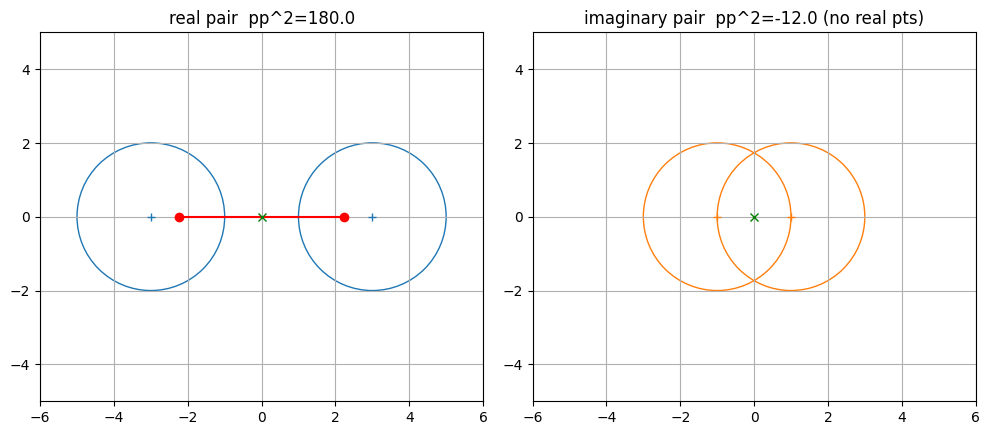

In [6]:
%matplotlib inline
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

def draw_circle(a, c, R, color):
    if R > 0:
        a.add_patch(plt.Circle(c, R**0.5, fill=False, color=color))
    a.plot(c[0], c[1], '+', color=color)

# real: two separated circles -> two real points
c1, c2, R = (3, 0), (-3, 0), 4.0
info = recover(conic_point(*c1, R) ^ conic_point(*c2, R))
for c in (c1, c2): draw_circle(ax[0], c, R, 'C0')
(Pa, Pb) = info['points']
ax[0].plot([Pa[0], Pb[0]], [Pa[1], Pb[1]], 'ro-')
ax[0].plot(*info['center'], 'gx')
ax[0].set_title('real pair  pp^2=%.1f' % info['pp2'])

# imaginary: two overlapping circles -> no real points
c1, c2, R = (1, 0), (-1, 0), 4.0
info = recover(conic_point(*c1, R) ^ conic_point(*c2, R))
for c in (c1, c2): draw_circle(ax[1], c, R, 'C1')
ax[1].plot(*info['center'], 'gx')
ax[1].set_title('imaginary pair  pp^2=%.1f (no real pts)' % info['pp2'])

for a in ax:
    a.set_aspect('equal'); a.grid(True); a.set_xlim(-6, 6); a.set_ylim(-5, 5)
plt.tight_layout(); plt.show()

## Your scratch space